<a href="https://colab.research.google.com/github/tunks/GA-ISYE-6501/blob/main/ISYE_6501_homework11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [55]:
###############################################
#  Homework 11 - 15.2
############

# install the required libaries
!pip install pulp openpyxl xlrd

#import required libries
import pandas as pd
import pulp

In [56]:

# -----------------------------
# Load data
# -----------------------------
file_name = "diet.xls"
diet_data = pd.read_excel(file_name)
print(diet_data)

                   Foods  Price/ Serving          Serving Size  Calories  \
0        Frozen Broccoli            0.16             10 Oz Pkg      73.8   
1            Carrots,Raw            0.07      1/2 Cup Shredded      23.7   
2            Celery, Raw            0.04               1 Stalk       6.4   
3            Frozen Corn            0.18               1/2 Cup      72.2   
4    Lettuce,Iceberg,Raw            0.02                1 Leaf       2.6   
..                   ...             ...                   ...       ...   
62  Crm Mshrm Soup,W/Mlk            0.65         1 C (8 Fl Oz)     203.4   
63  Beanbacn Soup,W/Watr            0.67         1 C (8 Fl Oz)     172.0   
64                   NaN             NaN                   NaN       NaN   
65                   NaN             NaN  Minimum daily intake    1500.0   
66                   NaN             NaN  Maximum daily intake    2500.0   

    Cholesterol mg  Total_Fat g  Sodium mg  Carbohydrates g  Dietary_Fiber g  \
0      

In [57]:
# Prepare and process the data
diet_data.columns = ["Food", "Price"] + list(diet_data.columns[2:])
diet_data["Food"] = diet_data["Food"].astype(str).str.strip()

# Convert numeric columns
for c in diet_data.columns[1:]:
    diet_data[c] = pd.to_numeric(diet_data[c], errors="coerce")

diet_data = diet_data.dropna(how="all").reset_index(drop=True)

# Locate min/max rows; otherwise use last 2 rows
min_rows = diet_data[diet_data["Food"].str.contains("min", case=False, na=False)].index.tolist()
max_rows = diet_data[diet_data["Food"].str.contains("max", case=False, na=False)].index.tolist()
min_idx, max_idx = (min_rows[0], max_rows[0]) if min_rows and max_rows else (len(diet_data)-2, len(diet_data)-1)

nutrient_cols = list(diet_data.columns[2:])
min_req = diet_data.loc[min_idx, nutrient_cols]
max_req = diet_data.loc[max_idx, nutrient_cols]

# Keep only food rows and valid nutrient columns
foods_df = diet_data.drop(index=[min_idx, max_idx]).copy()
foods_df = foods_df[foods_df["Price"].notna()].reset_index(drop=True)
good_cols = [c for c in nutrient_cols if pd.notna(min_req[c]) and pd.notna(max_req[c]) and foods_df[c].notna().all()]
foods_df = foods_df[["Food", "Price"] + good_cols]

foods = foods_df["Food"].tolist()
nutrients = good_cols
cost = dict(zip(foods, foods_df["Price"]))
nutrition = {n: dict(zip(foods, foods_df[n])) for n in nutrients}
min_req = min_req[nutrients]
max_req = max_req[nutrients]

print("Foods:", len(foods), "| Nutrients:", len(nutrients))

Foods: 64 | Nutrients: 11


In [58]:
### Part 1 - solution
m1 = pulp.LpProblem("Diet1", pulp.LpMinimize)
x = pulp.LpVariable.dicts("x", foods, lowBound=0)

# objective
m1 += pulp.lpSum(cost[f] * x[f] for f in foods)

# constraints
for n in nutrients:
    m1 += pulp.lpSum(nutrition[n][f] * x[f] for f in foods) >= float(min_req[n])
    m1 += pulp.lpSum(nutrition[n][f] * x[f] for f in foods) <= float(max_req[n])

m1.solve()

print("PART 1:", pulp.LpStatus[m1.status], "| Cost =", round(pulp.value(m1.objective), 4))

for f in foods:
    if x[f].value() and x[f].value() > 1e-6:
        print(f, round(x[f].value(), 4))

PART 1: Optimal | Cost = 4.3371
Frozen Broccoli 0.2596
Celery, Raw 52.6437
Lettuce,Iceberg,Raw 63.9885
Oranges 2.2929
Poached Eggs 0.1418
Popcorn,Air-Popped 13.8693


In [59]:
## Part 2 - solution
m2 = pulp.LpProblem("Diet2", pulp.LpMinimize)

x2 = pulp.LpVariable.dicts("x", foods, lowBound=0)
y = pulp.LpVariable.dicts("y", foods, cat="Binary")

# objective
m2 += pulp.lpSum(cost[f] * x2[f] for f in foods)

# nutrition constraints
for n in nutrients:
    m2 += pulp.lpSum(nutrition[n][f] * x2[f] for f in foods) >= float(min_req[n])
    m2 += pulp.lpSum(nutrition[n][f] * x2[f] for f in foods) <= float(max_req[n])

# (a) Add constraints
M = 100
for f in foods:
    m2 += x2[f] >= 0.1 * y[f]
    m2 += x2[f] <= M * y[f]

# (b) celery OR broccoli
celery = next((f for f in foods if "celery" in f.lower()), None)
broccoli = next((f for f in foods if "broccoli" in f.lower()), None)

if celery and broccoli:
    m2 += y[celery] + y[broccoli] <= 1

# (c) at least 3 protein foods
protein_words = ["beef","chicken","turkey","ham","pork","fish","tuna","egg","sausage","bologna","frankfurter"]
protein_foods = [f for f in foods if any(w in f.lower() for w in protein_words)]

if protein_foods:
    m2 += pulp.lpSum(y[f] for f in protein_foods) >= 3

m2.solve()

print("PART 2:", pulp.LpStatus[m2.status], "| Cost =", round(pulp.value(m2.objective), 4))

for f in foods:
    if y[f].value() and y[f].value() > 0.5:
        print(f, round(x2[f].value(), 4))

PART 2: Optimal | Cost = 4.513
Celery, Raw 42.423
Lettuce,Iceberg,Raw 82.6739
Oranges 3.0856
Poached Eggs 0.1
Scrambled Eggs 0.1
Bologna,Turkey 0.1
Peanut Butter 1.9591
Popcorn,Air-Popped 13.2145


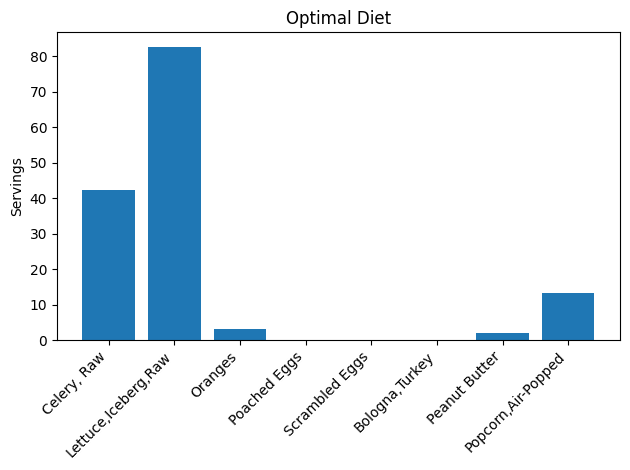

In [60]:
#Optional chart plot
import matplotlib.pyplot as plt

# Collect selected foods and servings
selected_foods = [f for f in foods if y[f].value() and y[f].value() > 0.5]
servings = [x2[f].value() for f in selected_foods]

# Plot
plt.figure()
plt.bar(selected_foods, servings)
plt.xticks(rotation=45, ha='right')
plt.title("Optimal Diet")
plt.ylabel("Servings")
plt.tight_layout()
plt.show()